In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

In [4]:
customer_data = pd.DataFrame({
    'age_group': rng.choice(['18-25', '26-35', '36-50', '51+'], 400, p=[.25, .35, .25, .15]),
    'frequency': rng.poisson(5,400),
    'monetary_value': rng.gamma(2.2, 180, 400).round(2)
})

customer_data["customer_segment"] = pd.qcut(customer_data["monetary_value"], 3, labels=["Low", "Mid", "High"])

In [5]:
sales_data = pd.DataFrame({
    'date': pd.date_range('2025-01-01', periods=120, freq='D'),
    'revenue': np.cumsum(rng.uniform(800, 3500, 120)),
})

In [6]:
product_data = pd.DataFrame({
    'category': ['Electronics', 'Clothing', 'Home', 'Toys'],
    'sales': rng.uniform(10_000, 50_000, 4)
})

In [16]:
social_data = pd.DataFrame(
    [(p,c, rng.uniform(0.5, 12))
     for p in ['Twitter', 'Instagram', 'Facebook']
     for c in ['Video', 'Image', 'Text']],
     
    columns = ['platform', 'content_type', 'engagement_rate']
)

### Plots

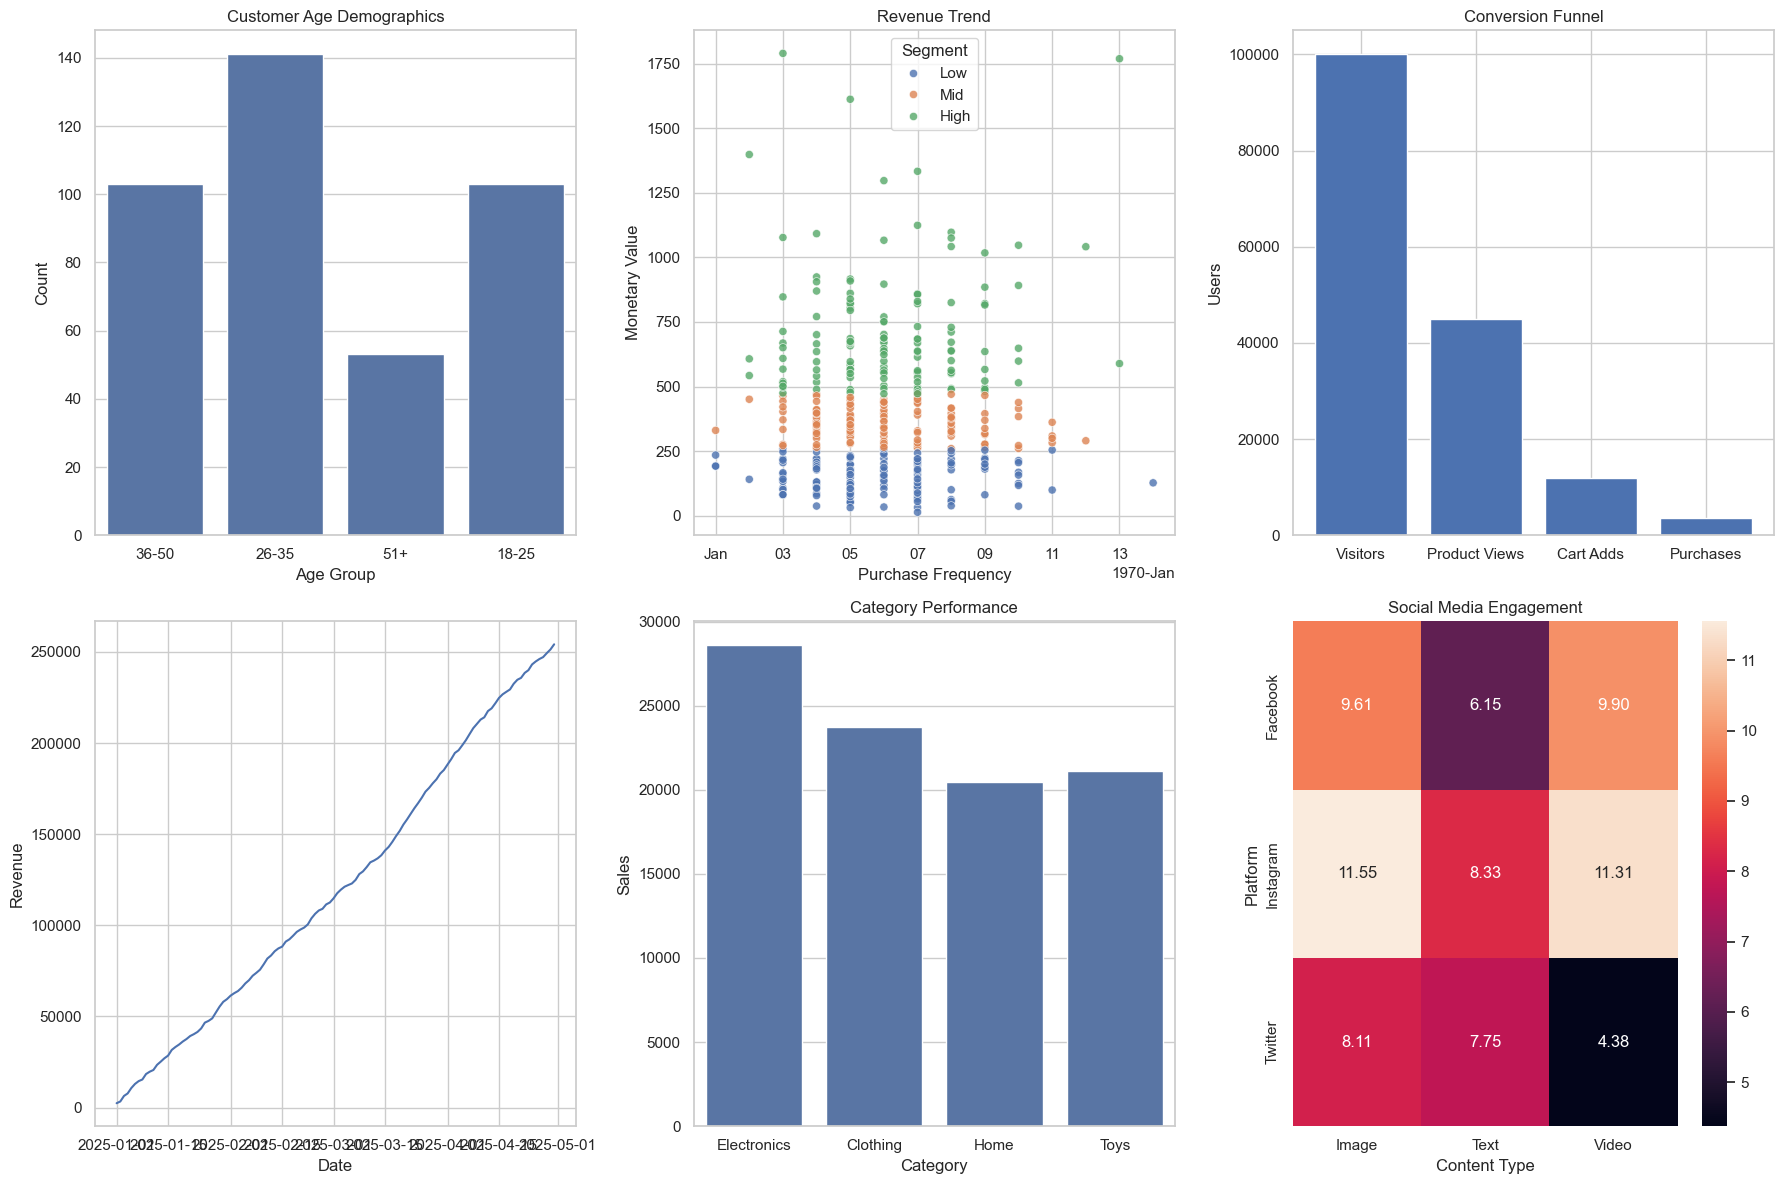

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Age Group Distribution

sns.countplot(data=customer_data, x='age_group', ax=axes[0,0])
axes[0,0].set_title('Customer Age Demographics')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Count')

# Plot 2: Purchase behavior

sns.scatterplot(data=customer_data, x='frequency', y='monetary_value', hue='customer_segment', ax=axes[0,1], s=35, alpha=0.8)
axes[0,1].set_title('Purchase Behavior Analysis')
axes[0,1].set_xlabel('Purchase Frequency')
axes[0,1].set_ylabel('Monetary Value')
axes[0,1].legend(title='Segment', loc='best')

# Plot 3: Conversion funnel

funnel_stages = ['Visitors', 'Product Views', 'Cart Adds', 'Purchases']
funnel_values = [100_000, 45_000, 12_000, 3_500]
axes[0,2].bar(funnel_stages, funnel_values)
axes[0,2].set_title('Conversion Funnel')
axes[0,2].set_ylabel('Users')

# Plot 4: Revenue Trend

sns.lineplot(data=sales_data, x='date', y='revenue', ax=axes[1,0])
axes[0,1].set_title('Revenue Trend')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Revenue')
loc =mdates.AutoDateLocator()
axes[1,0].xaxis.set_major_locator(loc)
axes[0,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

# Plot 5: Category performance

sns.barplot(data=product_data, x='category', y='sales', ax=axes[1,1])
axes[1,1].set_title('Category Performance')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Sales')

# Social engagement heatmap

engagement_matrix = social_data.pivot_table(index='platform', columns='content_type', values='engagement_rate', aggfunc='mean')
sns.heatmap(engagement_matrix, annot=True, fmt='.2f', ax=axes[1,2])
axes[1,2].set_title('Social Media Engagement')
axes[1,2].set_xlabel('Content Type')
axes[1,2].set_ylabel('Platform')
plt.tight_layout()
plt.show()